# Filter PrePPI by scores for 15k samples

## Load IXN file

In [1]:
import pandas as pd

In [ ]:
df_ppi = pd.read_csv('../../GraPPI_data/ppi_axin.csv',
                         names=['p1','p2','dom1','dom2','score','template'],
                         header=None, delim_whitespace=True,
                         dtype={'p1':'string','p2':'string','ppi_id1':'string','ppi_id2':'string','score':'float16','template':'string'},
                         usecols=['dom1','dom2','score','template'],
                         memory_map=True,
                         na_filter=False
                         )

/tmp/ipykernel_2851913/2817857601.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_ppi = pd.read_csv('/mnt/poisson/data/zhisong/ppi_axin.csv',


In [3]:
df_ppi

/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,dom1,dom2,score,template
0,000002,006613,0.160034,"1kyq:AB:e1kyqA2,e1kyqB2(0.34,0.54,20/362,4,1)"
1,000002.1_113,002668.7_131,0.449951,"7dni:IJ:7dni_I,7dni_J(0.50,0.36,1/1,1,0)"
2,000002,001897.128_211,0.870117,"5ltu:AB:5ltu_A,5ltu_B(0.02,0.35,5/23,1,0)"
3,000002.1_113,002621.253_464,0.280029,"3q4i:BA:e3q4iB2,e3q4iA1(0.18,0.41,17/313,0,0)"
4,000002,006613,0.160034,"1kyq:AB:e1kyqA2,e1kyqB2(0.34,0.54,20/362,4,1)"
...,...,...,...,...
25900689,002416.405_451,010792,0.870117,"3h1l:EP:3h1l_E,e3h1lP1(0.28,0.04,1/133,1,0)"
25900690,002416.318_362,008638.656_703,127.812500,"6g6q:DC:6g6q_D,6g6q_C(0.05,0.05,94/192,24,28)"
25900691,002416.489_538,016097,0.870117,"4olp:BA:4olp_B,4olp_A(0.18,0.19,3/151,1,0)"
25900692,002416.318_362,011654.660_759,14.101562,"5xzk:AB:5xzk_A,5xzk_B(0.13,0.26,86/96,19,22)"


## Check IXN stats

In [4]:
df_ppi['score'].describe()

/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan


count    2.590069e+07
mean              NaN
std      0.000000e+00
min      0.000000e+00
25%      2.199707e-01
50%      4.499512e-01
75%      8.701172e-01
max      3.858000e+03
Name: score, dtype: float64

In [5]:
# count how manny Nan in score
df_ppi['score'].min(), df_ppi['score'].max()

(np.float16(0.0), np.float16(3858.0))

(array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 7.7119e+04,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 6.7980e+04, 0.0000e+00,
        0.0000e+00, 1.5000e+01, 0.0000e+00, 0.0000e+00, 1.2408e+04,
        7.1617e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 4.3000e+02,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.6370e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 2.3072e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 5.1761e+04, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 2.9518e+04, 0.0000e+00,
        0.0000e+00, 4.0270e+03, 0.0000e+00, 0.00

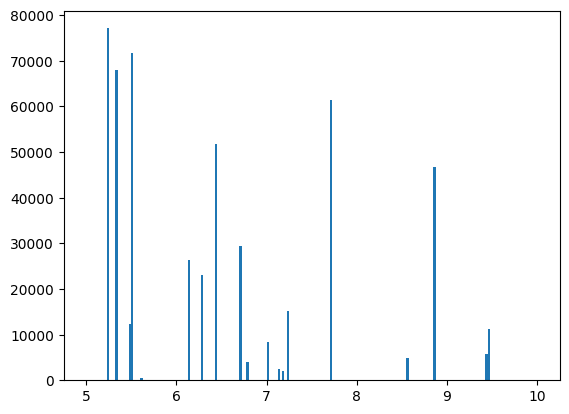

In [6]:
import matplotlib.pyplot as plt
plt.hist(df_ppi['score'], bins=200, range=(5,10))

In [ ]:
# sort by score and get the top 15000 negative samples
#df_ppi_sorted = df_ppi.sort_values(by='score', ascending=True)
#df_negative_samples = df_ppi_sorted.head(15000)
#df_negative_samples
# sort by score and get the sample with score between 2-10
df_ppi_sorted = df_ppi.sort_values(by='score', ascending=True)
df_negative_samples = df_ppi_sorted[(df_ppi_sorted['score'] >= 5) & (df_ppi_sorted['score'] <= 10)]
#df_negative_samples.to_csv('../../GraPPI_data/negative_samples.csv', index=False)
df_negative_samples

/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,dom1,dom2,score,template
8358604,001032.1059_1170,011341.517_695,5.230469,"3ph0:BD:3ph0_B,3ph0_D(0.02,0.16,38/85,3,0)"
1571152,000203.51_118,000787.270_355,5.230469,"4nik:BA:4nik_B,4nik_A(0.11,0.06,33/77,3,0)"
1081245,000137,014057.1_74,5.230469,"7c61:HA:7c61_H,e7c61A2(0.02,0.09,36/71,5,0)"
1208334,000157,018018.122_197,5.230469,"1mhh:CF:1mhh_C,1mhh_F(0.03,0.14,40/60,4,0)"
13548831,001462,002232.65_154,5.230469,"6tb4:JG:6tb4_J,e6tb4G2(0.08,0.11,23/37,1,0)"
...,...,...,...,...
2467768,000269,012703.1_122,9.460938,"6iap:EA:6iap_E,6iap_A(0.04,0.07,32/50,15,10)"
1081193,000137,006922,9.460938,"7xqv:BA:7xqv_B,7xqv_A(0.12,0.02,44/77,21,18)"
1029073,000130,015616.3_177,9.460938,"2uzi:HR:2uzi_H,2uzi_R(0.05,0.09,53/68,14,8)"
4509118,000610,003598,9.460938,"5d72:HA:e5d72H2,5d72_A(0.18,0.02,36/60,14,9)"


In [8]:
df_negative_samples.describe()

/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan


,score
count,522164.000000
mean,NaN
std,0.000000
min,5.230469
25%,5.328125
50%,6.289062
75%,7.238281
max,9.460938


## Get filtered samples from IXN file

In [9]:
df_tpl = df_negative_samples['template'].str.split(':', n=2, expand=True)
df_negative_samples['pdb_id'] = df_tpl[0]
df_negative_samples['chain_order'] = df_tpl[1]
# drop template column
df_negative_samples = df_negative_samples.drop(columns=['template'])
df_negative_samples.head()

/tmp/ipykernel_2851913/2672276826.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_negative_samples['pdb_id'] = df_tpl[0]
/tmp/ipykernel_2851913/2672276826.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_negative_samples['chain_order'] = df_tpl[1]
/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,dom1,dom2,score,pdb_id,chain_order
8358604,001032.1059_1170,011341.517_695,5.230469,3ph0,BD
1571152,000203.51_118,000787.270_355,5.230469,4nik,BA
1081245,000137,014057.1_74,5.230469,7c61,HA
1208334,000157,018018.122_197,5.230469,1mhh,CF
13548831,001462,002232.65_154,5.230469,6tb4,JG


In [ ]:
df_negative_samples.to_csv('../../GraPPI_data/ppi_axin_negative_df.csv', index=False,na_rep='')
#df_negative_samples.to_csv('../../GraPPI_data/ppi_axin_negative_df.csv', index=False)

## Check saved dataframe and remove experimental samples

In [1]:
import pandas as pd

In [ ]:
df_negative_samples = pd.read_csv('../../GraPPI_data/ppi_axin_negative_df.csv',
            keep_default_na=False,
            na_values=[])

In [3]:
df_negative_samples

,dom1,dom2,score,pdb_id,chain_order
0,001032.1059_1170,011341.517_695,5.23,3ph0,BD
1,000203.51_118,000787.270_355,5.23,4nik,BA
2,000137,014057.1_74,5.23,7c61,HA
3,000157,018018.122_197,5.23,1mhh,CF
4,001462,002232.65_154,5.23,6tb4,JG
...,...,...,...,...,...
518232,000269,012703.1_122,9.46,6iap,EA
518233,000137,006922,9.46,7xqv,BA
518234,000130,015616.3_177,9.46,2uzi,HR
518235,000610,003598,9.46,5d72,HA


In [ ]:
map_dict = {line.strip().split('\t>')[0]: set(line.strip().split('\t>')[1:])
    for line in open("/mnt/poisson/data/shares/PrePPI_PPIs/Human_af/map_list")}
expDB_set = [set(line.strip().split('_'))
             for line in open("/mnt/poisson/data/shares/PrePPI_PPIs/Human_af/human_allExpDB.csv")][1:]
expDB_lookup = {frozenset(x) for x in expDB_set}
# remove rows from df where the pair is in expDB_lookup
df_filtered = df_negative_samples[~df_negative_samples.apply(lambda row: any(frozenset((a, b)) in expDB_lookup
            for a in map_dict.get(row['dom1'].split('.')[0], []) for b in map_dict.get(row['dom2'].split('.')[0], [])), axis=1)]
df_filtered.to_csv('../../GraPPI_data/ppi_axin_negative_df.csv', index=False,na_rep='')


In [13]:
df_filtered

/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,dom1,dom2,score,pdb_id,chain_order
8358604,001032.1059_1170,011341.517_695,5.230469,3ph0,BD
1571152,000203.51_118,000787.270_355,5.230469,4nik,BA
1081245,000137,014057.1_74,5.230469,7c61,HA
1208334,000157,018018.122_197,5.230469,1mhh,CF
13548831,001462,002232.65_154,5.230469,6tb4,JG
...,...,...,...,...,...
2467768,000269,012703.1_122,9.460938,6iap,EA
1081193,000137,006922,9.460938,7xqv,BA
1029073,000130,015616.3_177,9.460938,2uzi,HR
4509118,000610,003598,9.460938,5d72,HA


# Run code to get aligned pdbs

```bash
python IXN2Pdb.py --IXN_csv_file ../../GraPPI_data/ppi_axin_negative_df.csv --base_dir /mnt/poisson/data/ssnegi/tmp_dir/Human1/Seqs/ --aligned_dir ../../GraPPI_data/preppi_aligned/
```

# Get preppi table with chain ids

In [7]:
import pandas as pd
import os
from tqdm import tqdm

In [ ]:
pdb_list = [fn.replace('.pdb', '') for fn in os.listdir('../../GraPPI_data/preppi_aligned/') if fn.endswith('.pdb')]

In [9]:
len(pdb_list)

15000

In [ ]:
# Initialize the DataFrame
df = pd.DataFrame(columns=['PDB', 'Receptor Chains', 'Ligand Chains', 'paths', 'affinity'])
# Populate the DataFrame
for pdb_id in tqdm(pdb_list):
    pdb_path = f'../../GraPPI_data/preppi_aligned/{pdb_id}.pdb'
    receptor_chain, ligand_chain = 'A', 'B'  # Placeholder for actual chain extraction logic
    new_row = {
		'PDB': pdb_id,
		'Receptor Chains': receptor_chain,
		'Ligand Chains': ligand_chain,
		'paths': pdb_path,
		'affinity': -1
	}
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

df

100%|██████████| 15000/15000 [00:02<00:00, 5608.37it/s]


,PDB,Receptor Chains,Ligand Chains,paths,affinity
0,M001003.1_71_M002494,A,B,/mnt/poisson/data/zhisong/preppi_aligned/M0010...,-1
1,M001307.270_355_M018316,A,B,/mnt/poisson/data/zhisong/preppi_aligned/M0013...,-1
2,M000270_M002652.1_147,A,B,/mnt/poisson/data/zhisong/preppi_aligned/M0002...,-1
3,M002068.396_524_M017065.37_135,A,B,/mnt/poisson/data/zhisong/preppi_aligned/M0020...,-1
4,M000333_M015620.146_272,A,B,/mnt/poisson/data/zhisong/preppi_aligned/M0003...,-1
...,...,...,...,...,...
14995,M000158_M004342,A,B,/mnt/poisson/data/zhisong/preppi_aligned/M0001...,-1
14996,M000597_M005513,A,B,/mnt/poisson/data/zhisong/preppi_aligned/M0005...,-1
14997,M000264_M003285.49_160,A,B,/mnt/poisson/data/zhisong/preppi_aligned/M0002...,-1
14998,M000107_M012465.618_872,A,B,/mnt/poisson/data/zhisong/preppi_aligned/M0001...,-1


In [11]:
df.to_csv('./saved_tables/preppi_db.csv', index=False)